# Train experts that merge well

**HF ViT-Tiny → objects + digits → FT / SMAT → AVG / Task Arithmetic**

One expert learns CIFAR-10 objects; another learns SVHN street-view digits. Both start from the same pretrained encoder. Can training with merging in mind produce a better **single merged encoder**?

This small CPU-ready example imports the real SMAT implementation. All four experts train below. [Paper](https://arxiv.org/abs/2609.33437) · [Code](https://github.com/egangu/smat) · [Data](https://huggingface.co/datasets/yanggangu/SMAT-Tiny-Demo)


### 1. Setup
Run all cells in order. Default: **CPU, 4 threads, seed 0**. Downloads: approximately **23 MB weights + 22 MB data**. The setup installs only missing lightweight dependencies and SMAT without its research extras; Colab normally already has PyTorch.

Only support files are fetched here. The expert training and merging code stays visible below.


In [1]:
from pathlib import Path
from urllib.request import urlretrieve
import hashlib

SUPPORT_REVISION = "5418a3e30a7b32c65711f728a42611d061af0adb"
SUPPORT_FILES = {'demo_setup.py': 'b4e2bd5af77d7e38c23425803a6cb9bafce73cfb31e88c20bb29e4ba1a9c37f7', 'demo_utils.py': '2b71e9520c87185668c1b2f96c792fcf602ee45b0890982c2b6e051942d5eb70', 'demo_experiment.py': '2545328171579e818264859922f73a6225cb5eed8705dd7cc7cfdd8f0589dd70'}
for name, digest in SUPPORT_FILES.items():
    if not Path(name).exists():
        urlretrieve(f"https://raw.githubusercontent.com/egangu/smat/{SUPPORT_REVISION}/examples/{name}", name)
    assert hashlib.sha256(Path(name).read_bytes()).hexdigest() == digest, f"Unexpected helper: {name}"
from demo_setup import ensure_runtime
ensure_runtime()


In [2]:
import os
from copy import deepcopy
import torch
from torch import nn
from torch.nn import functional as F
import pandas as pd
import matplotlib.pyplot as plt
from smat.train.updates import FTStepper, SMATStepper
from demo_utils import load_encoder, load_data, show_examples, show_results
from demo_experiment import fit_heads

DEVICE = os.environ.get("SMAT_DEMO_DEVICE", "cpu")  # Change to "cuda" if available.
SEED = 0
torch.set_num_threads(4)
torch.manual_seed(1729)  # Same initialization for every expert.
TASKS = ("cifar10", "svhn")


/work/home/yggu/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2. Two different tasks, one HF base
Use the original [ViT-Tiny pretrained weights](https://huggingface.co/timm/vit_tiny_patch16_224.augreg_in21k_ft_in1k), with 64×64 inputs. Cache the frozen patch embedding once to save work. **All 12 Transformer blocks are trainable.** Each task has 2,000 training and 2,000 test images.

Fit a small head for each task using its training images, while the HF encoder stays unchanged; then freeze both heads. This is the **Base** used by both methods. Heads have different label meanings and are never averaged.


In [3]:
class TwoTaskViT(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = nn.Sequential(deepcopy(backbone.blocks), deepcopy(backbone.norm))
        self.heads = nn.ModuleDict({task: nn.Linear(192, 10) for task in TASKS})

    def features(self, tokens):
        return self.backbone(tokens)[:, 0]

    def forward(self, tokens, task):
        return self.heads[task](self.features(tokens))


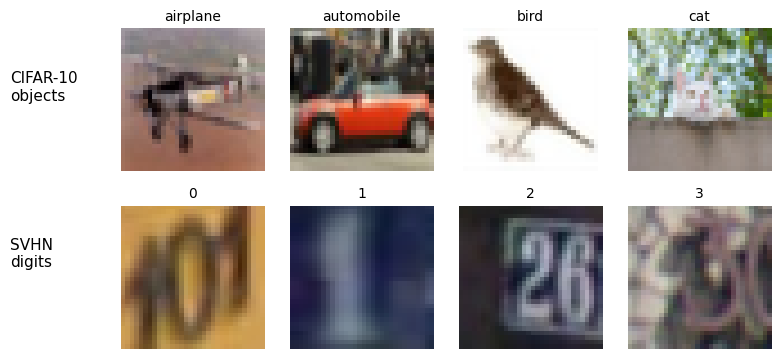

In [4]:
encoder = load_encoder().to(DEVICE).eval()
base = TwoTaskViT(encoder).to(DEVICE).eval()
data = load_data(encoder, DEVICE)
fit_heads(base, data)
del encoder
figure = show_examples()
plt.show()


### 3. Train independent experts
FT and SMAT use **identical initialization, minibatches, Adam learning rate and update count**. Each expert sees only its own task. Every fourth SMAT update simulates **Scale · Mask · Perturb**; the imported `SMATStepper` performs the transformation, gradient calculation and restoration.


In [5]:
SMAT_SETTINGS = {
    "backend": "eager",
    "scale": {"alpha_min": 0.1},
    "mask": {"probability": 0.8},
    "perturb": {"rms": 0.01},
    "smat": {"interval": 4},
}

def train_expert(base, data, task, method, seed=0):
    """Same initialization, Adam, batches and 600 updates for FT and SMAT."""
    if method not in {"FT", "SMAT"}:
        raise ValueError("method must be FT or SMAT")
    expert = deepcopy(base)
    parameters = list(expert.named_parameters())
    optimizer = torch.optim.Adam([p for _, p in parameters if p.requires_grad], lr=1e-4)
    linear_weights = {n for n, p in parameters if p.requires_grad and p.ndim == 2}
    stepper = (
        FTStepper(parameters, optimizer) if method == "FT" else
        SMATStepper(parameters, optimizer, SMAT_SETTINGS, seed, linear_weights)
    )
    x, y = data[task]["train"]
    rng = torch.Generator().manual_seed(seed + 100)
    for _ in range(600):
        ids = torch.randint(len(y), (32,), generator=rng).to(y.device)
        stepper.step(lambda: F.cross_entropy(expert(x[ids], task), y[ids]))
    return expert.eval()


In [6]:
experts = {}
for method in ("FT", "SMAT"):
    experts[method] = []
    for task in TASKS:
        print(f"Training {method}: {task}", flush=True)
        experts[method].append(train_expert(base, data, task, method, SEED))


Training FT: cifar10


Training FT: svhn


Training SMAT: cifar10


Training SMAT: svhn


### 4. Merge and evaluate
For task updates $\Delta_1$ and $\Delta_2$, use $\theta_{\rm base}+\lambda(\Delta_1+\Delta_2)$.
**AVG:** $\lambda=0.5$. **TA:** $\lambda=0.75$. Coefficients are fixed and shared by FT/SMAT.

Each merged model has **one encoder and two frozen heads**; evaluation knows which task to use.


In [7]:
def merge_experts(base, experts, coefficient):
    """AVG: 0.5. TA: 0.75. Keep both task-specific heads unchanged."""
    merged = deepcopy(base)
    anchor = base.backbone.state_dict()
    states = [expert.backbone.state_dict() for expert in experts]
    merged.backbone.load_state_dict({
        name: value + coefficient * sum(state[name] - value for state in states)
        for name, value in anchor.items()
    })
    return merged.eval()

@torch.no_grad()
def evaluate(model, data):
    scores = {}
    for task in TASKS:
        x, y = data[task]["test"]
        predictions = torch.cat([model(batch, task).argmax(1) for batch in x.split(128)])
        scores[task] = 100 * (predictions == y).sum().item() / len(y)
    scores["Mean"] = sum(scores.values()) / len(TASKS)
    return scores


In [8]:
rows = {"Base": evaluate(base, data)}
for method in ("FT", "SMAT"):
    for merger, coefficient in (("AVG", 0.5), ("TA", 0.75)):
        merged = merge_experts(base, experts[method], coefficient)
        rows[f"{method} {merger}"] = evaluate(merged, data)
        del merged
pd.DataFrame(rows).T.rename(columns={"cifar10": "CIFAR-10", "svhn": "SVHN"}).round(2)


,CIFAR-10,SVHN,Mean
Base,44.55,21.25,32.90
FT AVG,61.20,58.30,59.75
FT TA,61.85,67.90,64.88
SMAT AVG,65.25,67.05,66.15
SMAT TA,66.55,72.90,69.72


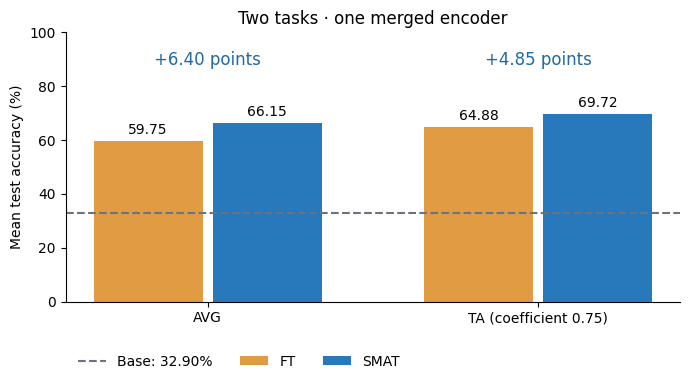

AVG: SMAT − FT = +6.40 percentage points
TA: SMAT − FT = +4.85 percentage points


In [9]:
figure = show_results(rows)
plt.show()
for merger in ("AVG", "TA"):
    gain = rows[f"SMAT {merger}"]["Mean"] - rows[f"FT {merger}"]["Mean"]
    print(f"{merger}: SMAT − FT = {gain:+.2f} percentage points")


### What to look for
Both FT and SMAT merged models should improve on Base. The important comparison is **SMAT versus FT at the same merge rule and training budget**.

With this frozen recipe, five predeclared CUDA seeds give average gains of **+5.07 points (AVG)** and **+4.07 (TA)**. The CPU default seed gives **+6.40 / +4.85**. These are measured results, not guarantees for every seed or software environment; one CUDA TA seed gains +2.65. Training randomness and floating-point calculations can change individual results.

This is an illustrative small-data experiment, not a reproduction of the paper's benchmark or <2% overhead measurement. The recipe was frozen before test evaluation; there is no development-set tuning in this notebook. [Recipe, all seeds and validation](https://github.com/egangu/smat/tree/main/examples).
